# Correlation with Tokyo Weather

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from meteostat import Point, Hourly


plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

In [2]:
TOKYO = Point(35.6812, 139.7671)
START = datetime(2024, 1, 1)
END = datetime(2024, 3, 31)

df = Hourly(TOKYO, START, END).fetch()

if df.index.tz is None:
    df = df.tz_localize('UTC').tz_convert('Asia/Tokyo')
else:
    df = df.tz_convert('Asia/Tokyo')

cols = [c for c in ['temp','rhum','wspd','pres','dwpt'] if c in df.columns]
df = df[cols]

df = df[~df.index.duplicated(keep='first')]
df = df.asfreq('1h')

print("Columns available:", list(df.columns))
print(df.head())

Columns available: ['temp', 'rhum', 'wspd', 'pres', 'dwpt']
                           temp  rhum  wspd    pres  dwpt
time                                                     
2024-01-01 09:00:00+09:00   9.7  46.0  20.5  1018.6  -1.4
2024-01-01 10:00:00+09:00  10.6  40.0  29.5  1019.3  -2.4
2024-01-01 11:00:00+09:00  11.5  41.0  20.5  1019.2  -1.3
2024-01-01 12:00:00+09:00  11.6  37.0  18.4  1019.2  -2.6
2024-01-01 13:00:00+09:00  11.8  34.0  20.5  1019.6  -3.6


In [3]:
def rh_from_temp_dewpoint(temp_c, dewpoint_c):
    a, b = 17.625, 243.04
    es  = 6.1094 * np.exp(a * temp_c     / (b + temp_c))
    e   = 6.1094 * np.exp(a * dewpoint_c / (b + dewpoint_c))
    return 100.0 * (e / es)

if 'rhum' not in df.columns and {'temp','dwpt'}.issubset(df.columns):
    df['rhum'] = rh_from_temp_dewpoint(df['temp'], df['dwpt']).clip(0, 100)

In [4]:
def xcorr(a: pd.Series, b: pd.Series, max_lag_hours: int = 72) -> pd.Series:
    joined = pd.concat([a, b], axis=1).dropna()
    if joined.empty or len(joined) < 24:
        raise ValueError("Not enough overlapping data to compute correlation.")
    x = (joined.iloc[:,0] - joined.iloc[:,0].mean()) / joined.iloc[:,0].std()
    y = (joined.iloc[:,1] - joined.iloc[:,1].mean()) / joined.iloc[:,1].std()
    lags = np.arange(-max_lag_hours, max_lag_hours + 1, dtype=int)
    vals = []
    for L in lags:
        if L < 0:
            vals.append(np.corrcoef(x[-L:], y[:len(y)+L])[0,1])
        elif L > 0:
            vals.append(np.corrcoef(x[:len(x)-L], y[L:])[0,1])
        else:
            vals.append(np.corrcoef(x, y)[0,1])
    return pd.Series(vals, index=lags)

def znorm(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / s.std()

## Day 4

ACF strongest repeating lag ≈ -1 h (daily cycle visible)


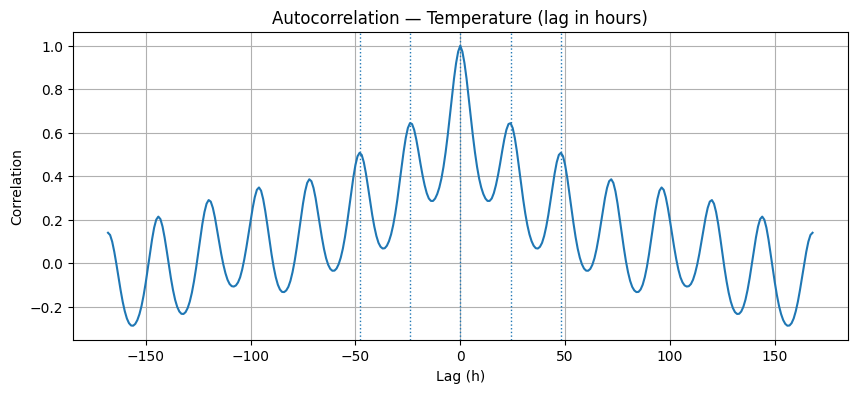

In [5]:
acf_temp = xcorr(df['temp'], df['temp'], max_lag_hours=168)
ax = acf_temp.plot(title="Autocorrelation — Temperature (lag in hours)")
ax.set_xlabel("Lag (h)"); ax.set_ylabel("Correlation")
for k in (-48, -24, 0, 24, 48):
    ax.axvline(k, linestyle=':', linewidth=1)

# strongest non-zero peak (avoid trivial zero-lag)
peak_lag = acf_temp.drop(0).abs().idxmax()
print(f"ACF strongest repeating lag ≈ {peak_lag} h (daily cycle visible)")

Tokyo temperature clearly repeats on a daily rhythm; the ACF peaks near 24 hours confirm a strong day–night cycle.

## Day 5

### What we learned from Day 4

- Tokyo temperature has a strong daily rhythm (~24 hours).

- There are smaller within-day wiggles.

- Days are similar but not identical, so any lead/lag with other variables will likely be a few hours.

### Use case

- See how temperature relates to humidity and wind speed in Tokyo.

- Answer two questions:

    - Do they move together or opposite?

    - Who moves first, and by how many hours?

### Why we’re using correlation

- Autocorrelation: confirms the daily pattern is real and worth tracking.

- Cross-correlation: shows lead/lag relationships (e.g., wind picks up, then cooling follows).

### What we’ll report

- Sign of the link: positive or negative.

- Peak lag (hours) where the link is strongest, plus a one-line takeaway (e.g., “wind tends to lead temperature by ~3 h”).

- Clear plots with vertical lines at 0 and ±24 h to make timing easy to read.


## Day 6

In [9]:
pairs = []
if 'rhum' in df.columns: pairs.append(("Temp ↔ Humidity", 'temp', 'rhum'))
if 'wspd' in df.columns: pairs.append(("Temp ↔ Wind",     'temp', 'wspd'))

rows = []
series_for_plots = {}

for name, a, b in pairs:
    s = xcorr(df[a], df[b], max_lag_hours=72)  # REUSE Day 4's xcorr
    series_for_plots[name] = s
    lag = int(s.abs().idxmax())
    r   = float(s.loc[lag])
    sign = "positive" if r >= 0 else "negative"
    interp = (
        f"{b} lags {a} by {lag} h (temp leads)" if lag > 0 else
        f"{b} leads {a} by {abs(lag)} h" if lag < 0 else
        "move together (0 h lag)"
    )
    rows.append((name, sign, lag, r, interp))

summary = pd.DataFrame(rows, columns=["Pair","Sign","Peak lag (h)","Correlation","Interpretation"])
summary

,Pair,Sign,Peak lag (h),Correlation,Interpretation
0,Temp ↔ Humidity,positive,-14,0.282990,rhum leads temp by 14 h
1,Temp ↔ Wind,positive,25,0.249694,wspd lags temp by 25 h (temp leads)


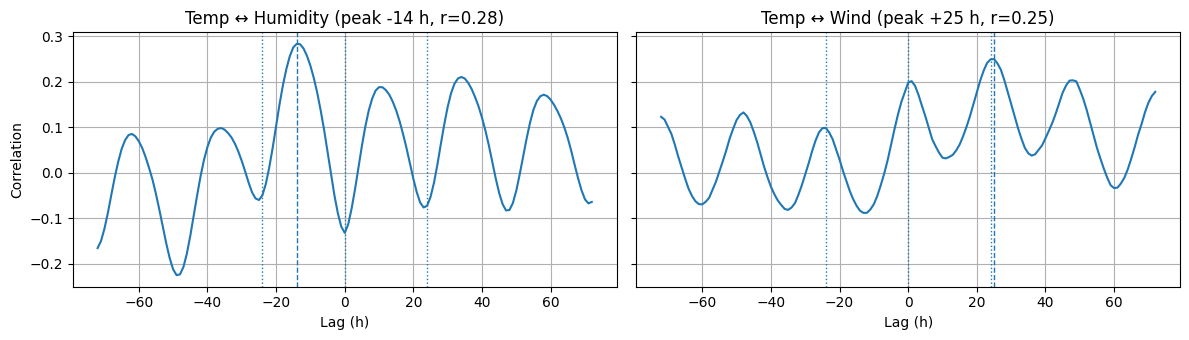

In [10]:
n = len(series_for_plots)
if n:
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3.5*rows), sharex=True, sharey=True)

    axes = np.atleast_1d(axes).ravel()  # robust: 1 or many axes

    for i, (name, s) in enumerate(series_for_plots.items()):
        ax = axes[i]
        s.plot(ax=ax)

        # Day 4 markers
        for k in (-24, 0, 24):
            ax.axvline(k, linestyle=':', linewidth=1)

        # mark peak lag
        lag = s.abs().idxmax()
        ax.axvline(lag, linestyle='--', linewidth=1)

        ax.set_title(f"{name} (peak {lag:+} h, r={s.loc[lag]:.2f})")
        ax.set_xlabel("Lag (h)")
        ax.set_ylabel("Correlation")

    # hide any unused subplots
    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

### Temp ↔ Humidity:
The strongest peak shows up at −14 h (r≈0.28), which means humidity leads temperature by ~14 hours. Because this is close to a 24-hour shift, it mainly reflects the daily rhythm we saw in Day 4 (not a direct, causal lead).

### Temp ↔ Wind:
The strongest peak is +25 h (r≈0.25), meaning wind lags temperature by ~25 hours. Again, that’s essentially “yesterday’s pattern repeating” (24 h), not a same-day cause/effect.

In [11]:
def near_zero_peak(s, w=6):
    win = s.loc[-w:w]
    lag = int(win.abs().idxmax())
    r   = float(win.loc[lag])
    return lag, r

results = []
if 'rhum' in df.columns:
    s = xcorr(df['temp'], df['rhum'], 72)
    lag, r = near_zero_peak(s, 6)
    results.append(("Temp ↔ Humidity (±6 h)", lag, r))
if 'wspd' in df.columns:
    s = xcorr(df['temp'], df['wspd'], 72)
    lag, r = near_zero_peak(s, 6)
    results.append(("Temp ↔ Wind (±6 h)", lag, r))

pd.DataFrame(results, columns=["Pair (same-day window)","Peak lag (h)","Correlation"])

,Pair (same-day window),Peak lag (h),Correlation
0,Temp ↔ Humidity (±6 h),0,-0.132041
1,Temp ↔ Wind (±6 h),1,0.201061
